# MauFlex: Automatic Segmentation of *Mauritia flexuosa* in UAV Imagery — single-image inference

Reproduction of **Morales, G.; Kemper, G.; Sevillano, G.; Arteaga, D.; Ortega, I.; Telles, J.
"Automatic Segmentation of *Mauritia flexuosa* in Unmanned Aerial Vehicle (UAV) Imagery Using Deep Learning."
*Forests* 2018, 9(12), 736.** [DOI 10.3390/f9120736](https://doi.org/10.3390/f9120736)

**What this notebook does (executed scope):** loads the authors' trained Deeplab v3+-style network
(`Redes/Final_DeeplabG1.h5`) and reproduces the headless core of their GUI software
(`aguaje_functions.py::detectaguaje`, repo pinned at commit `71c6c2367733`): 512×512 sliding-window
tiling with 50-px overlap, tile-wise prediction, max-merge into a probability map, thresholding and
small-component removal — on **one** repository test image (`test_images/1.jpg`), then compares the
result with the authors' own released mask (`test_images/Resultados/1_mask.tif`).

**What is NOT reproduced:** training (requires the MauFlex dataset archive), the Tkinter GUI,
georeferenced mosaic monitoring, and the paper's dataset-level accuracy numbers (98.143% test accuracy).
A one-image run is a demonstration, not a verification of published metrics.

**Status:** EXECUTED (validated end-to-end on a fresh Colab CPU runtime).

**日本語の概要:** このノートブックは、著者らの学習済みモデル `Final_DeeplabG1.h5` を読み込み、
著者提供コード `aguaje_functions.py` の推論部(512×512 スライディングウィンドウ+50px オーバーラップ、
確率マップ統合、閾値処理、小領域除去)を 1 枚のテスト画像 `1.jpg` で再現し、著者公開の参照マスク
`1_mask.tif` と比較します。学習・GUI・モザイク処理は対象外です。

## Runtime selection — how to run

**Select Runtime → Change runtime type → CPU (recommended).** The network is small (≈0.51 M parameters,
512×512×3 input) and one image needs only 15 tiles, so CPU inference takes well under a minute.
The code is device-agnostic: if a GPU runtime (T4) is selected instead, TensorFlow uses it automatically and
the same cells run unchanged, only faster.

- Expected end-to-end time: ≈ 3–6 minutes (downloads ≈ 10 MB, model load, 15 tile predictions, figures).
- **Runtime → Run all** executes everything top to bottom. No login, tokens, Drive mount, or manual steps are needed.

**日本語:** ランタイム種別は **CPU を推奨**(モデルが小型のため)。GPU(T4)でも同一コードで動作します。
「ランタイム → すべてのセルを実行」で完結します(所要 3〜6 分、ダウンロード約 10 MB)。

## Setup: dependencies

The minimal reproduction needs only `tensorflow`, `opencv-python` (cv2), `numpy`, `tifffile`, `matplotlib`,
and `pandas` — all preinstalled on current Colab runtimes, so **no pip install is required**. We verify the
versions actually used so the record is reproducible. The author's GUI-only dependencies (`tkinter`,
`natsort`, `cx_Freeze`) are intentionally not used.

**日本語:** 必要な依存パッケージ(tensorflow, opencv, numpy, tifffile, matplotlib, pandas)は Colab に
プリインストール済みのため、インストールは不要です。実行時バージョンを記録します。

In [ ]:
import sys, importlib
print("python", sys.version.split()[0])
for pkg in ["tensorflow", "cv2", "numpy", "tifffile", "matplotlib", "pandas"]:
    m = importlib.import_module(pkg)
    print(f"{pkg:12s}", getattr(m, "__version__", "n/a"))
import tensorflow as tf
print("visible GPUs:", tf.config.list_physical_devices("GPU"))

python 3.13.16


tensorflow   2.21.0
cv2          5.0.0
numpy        2.1.3


tifffile     2026.9.20
matplotlib   3.10.0
pandas       2.2.3
visible GPUs: []


## Inputs: provenance-pinned download

Everything is fetched directly from the authors' public repository at the pinned commit
`71c6c2367733a2baa6da2774dce3f8b64d922e36`:

| File | Role | Bytes | Git blob SHA-1 |
| --- | --- | --- | --- |
| `Redes/Final_DeeplabG1.h5` | trained model weights | 2,254,624 | `c0b57381…` |
| `test_images/1.jpg` | UAV test image (input) | 4,853,264 | `b5f1eb2b…` |
| `test_images/Resultados/1_mask.tif` | authors' released output mask (reference) | 3,003,498 | `96566263…` |

**日本語:** 入力は著者の公開リポジトリ(pin したコミット)から直接ダウンロードし、Git blob SHA-1 で
バイト完全性を検証します。重み・画像・参照マスクの 3 ファイルのみ(合計約 10 MB)。

The next cell downloads the three artifacts and asserts size **and** git blob SHA-1
(`sha1("blob <size>\0" + content)`), rejecting truncated or tampered files. This is the same integrity
check GitHub itself uses for stored objects.

**日本語:** 次のセルで 3 ファイルを取得し、サイズと Git blob SHA-1 の両方を検証します(不一致なら停止)。

In [ ]:
import urllib.request, hashlib, os

COMMIT = "71c6c2367733a2baa6da2774dce3f8b64d922e36"
RAW = f"https://raw.githubusercontent.com/GiorgioMorales/MauFlex/{COMMIT}/"
os.makedirs("/content/mauflex", exist_ok=True)

PINNED = {
    "Final_DeeplabG1.h5": ("Redes/Final_DeeplabG1.h5", 2254624, "c0b57381fdb48428c6fff0b15e3553bfa2174f99"),
    "1.jpg":              ("test_images/1.jpg", 4853264, "b5f1eb2b8a2c0259007174ef000a26e1d0bd26cc"),
    "1_mask.tif":         ("test_images/Resultados/1_mask.tif", 3003498, "965662631334de23e6d0c0f1a58f8fcd62e5b4a3"),
}

for dest, (repo_path, size, blob) in PINNED.items():
    out = f"/content/mauflex/{dest}"
    urllib.request.urlretrieve(RAW + repo_path, out)
    content = open(out, "rb").read()
    assert len(content) == size, f"{repo_path}: expected {size} bytes, got {len(content)}"
    assert hashlib.sha1(b"blob %d\x00" % len(content) + content).hexdigest() == blob, f"{repo_path}: blob SHA mismatch"
    print(f"verified {repo_path}  ({len(content)} bytes, blob SHA-1 OK)")
# reject Git LFS pointer text masquerading as a payload (real HDF5 signature)
assert open("/content/mauflex/Final_DeeplabG1.h5", "rb").read(8) == b"\x89HDF\r\n\x1a\n", "not a valid HDF5 file" 

verified Redes/Final_DeeplabG1.h5  (2254624 bytes, blob SHA-1 OK)
verified test_images/1.jpg  (4853264 bytes, blob SHA-1 OK)


verified test_images/Resultados/1_mask.tif  (3003498 bytes, blob SHA-1 OK)


## Load the trained model

`Final_DeeplabG1.h5` is a legacy Keras 2.x H5 saved by the authors. Their loader
(`aguaje_functions.py::build_aguaje`) registers one custom activation, `relu6` (ReLU clipped at 6), which we
re-implement identically with `tf.keras.activations.relu(x, max_value=6)`. The file contains only standard
layer classes (Conv2D, SeparableConv2D, DepthwiseConv2D, BatchNormalization, Activation, Add, Concatenate,
UpSampling2D, Dropout — no `Lambda` layers), so modern TensorFlow/Keras (validated on TF 2.21 / Keras 3.13)
loads it directly with `compile=False` (inference only; the authors' loss/metric objects are not needed).
The original `K.set_learning_phase(0)` is the TF1-era equivalent of inference mode; `predict()` already
runs inference-mode, so no learning-phase call is required.

**日本語:** 著者の `build_aguaje` と同様に `custom_objects={'relu6': ...}` を登録して H5 を読み込みます。
レイヤーはすべて標準クラスのため TF 2.21/Keras 3.13 で直接ロードできます(`compile=False`)。
入力 (512,512,3)、出力 (512,512,1) のセグメンテーションネットワークです。

In [ ]:
import tensorflow as tf

def relu6(x):
    return tf.keras.activations.relu(x, max_value=6.0)

model = tf.keras.models.load_model(
    "/content/mauflex/Final_DeeplabG1.h5",
    custom_objects={"relu6": relu6},
    compile=False,
)
print("input :", model.input_shape)
print("output:", model.output_shape)
print("params:", model.count_params())

input : (None, 512, 512, 3)
output: (None, 512, 512, 1)
params: 507729


## Input preview (before any analysis)

`test_images/1.jpg` is a 4000×6000 (H×W) UAV RGB photograph of an aguajal near Iquitos, Peru — one of the
twelve test images shipped in the repository. Alongside it we display the authors' released reference mask
`1_mask.tif` (white = *Mauritia flexuosa* palm crowns, 1-bit GeoTIFF). This is a direct look at the real
inputs before running any science. The reference mask is the authors' own output for this image, stored at
the original resolution.

**日本語:** 入力画像 `1.jpg`(4000×6000 の UAV 航空写真)と、著者らが公開している参照マスク
`1_mask.tif`(白 = *M. flexuosa* の樹冠)を並べて表示します。分析前に実データを確認する工程です。

input image  (H,W,C): (4000, 6000, 3)
reference mask      : (4000, 6000) palm fraction 0.536


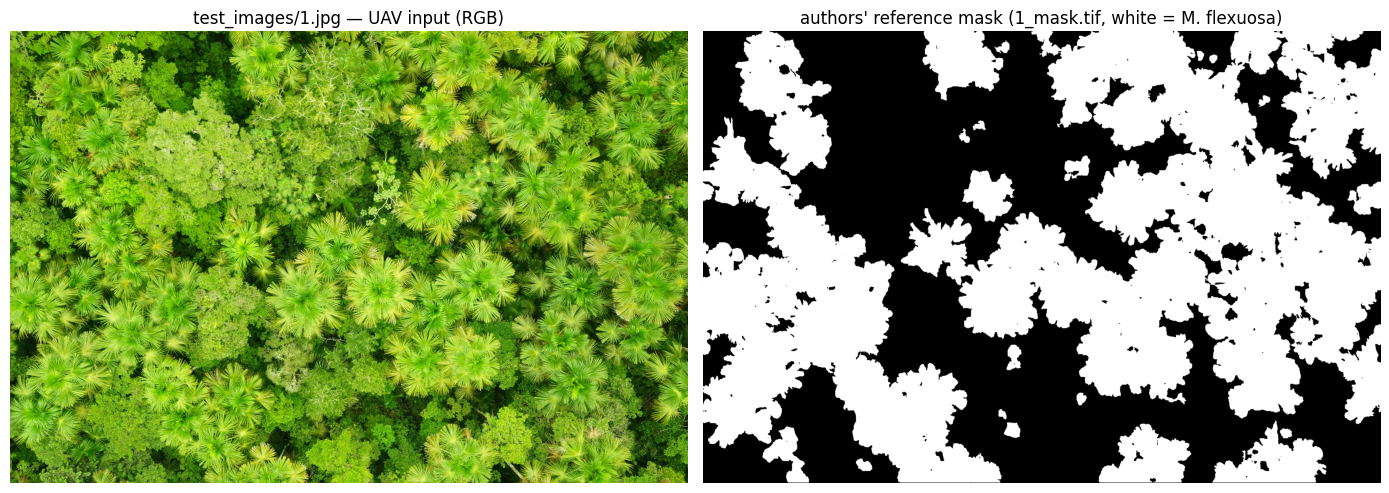

In [ ]:
import numpy as np, cv2
from PIL import Image

img_bgr = cv2.imread("/content/mauflex/1.jpg")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # author code: cv2 BGR -> RGB merge
H0, W0 = img.shape[:2]
ref = np.array(Image.open("/content/mauflex/1_mask.tif")).astype(np.uint8)
print("input image  (H,W,C):", img.shape)
print("reference mask      :", ref.shape, "palm fraction %.3f" % (ref > 0).mean())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img); axes[0].set_title("test_images/1.jpg — UAV input (RGB)")
axes[1].imshow(ref, cmap="gray"); axes[1].set_title("authors' reference mask (1_mask.tif, white = M. flexuosa)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Faithful port of `detectaguaje` — step 1: tiling with 50-px overlap

We copy the author's exact window logic from `aguaje_functions.py` (lines 45–77), keeping their variables
(`n1, s1, n2, s2`, 50-px overlap offset, resize of each window to 512×512). Two documented adaptations, no
scientific change: (1) the downsize rule `M≥4000 and N≥6000 → cv2.resize(3000, 2000)` uses the
author's condition; (2) the author's prediction loop feeds `Blocks[u*5:]` on its final iteration, which is an
**empty slice when the tile count is a multiple of 5** (here 15 tiles) — our port skips empty slices.

**日本語:** 著者コードのタイル分割(512×512、50px オーバーラップ、各窓を 512×512 へリサイズ)をそのまま
移植します。画像は M≥4000 かつ N≥6000 のため 3000×2000 に縮小され、15 タイルになります。
著者ループの最終バッチが空になる(タイル数が 5 の倍数の場合)エッジケースのみ、空スライスをスキップする
よう修正しています(科学的手法に変更なし)。

In [ ]:
def author_windows(img_rgb):
    # exact port of aguaje_functions.py lines 45-77 (author variables kept)
    [M, N, P] = img_rgb.shape
    if M >= 4000 and N >= 6000:                       # author's downsize rule
        img_rgb = cv2.resize(img_rgb, (3000, 2000))   # (width, height)
    n1 = int(np.floor(img_rgb.shape[0] / 512))        # segments in X (rows)
    s1 = int(np.floor(img_rgb.shape[0] / n1))         # step in X
    n2 = int(np.floor(img_rgb.shape[1] / 512))        # segments in Y (cols)
    s2 = int(np.floor(img_rgb.shape[1] / n2))         # step in Y

    Blocks = np.zeros((n1 * n2, 512, 512, 3)).astype(np.uint8)
    cnt = 0
    for x in range(0, n1):
        for y in range(0, n2):
            if x == 0 and y == 0:
                Blocks[cnt] = cv2.resize(img_rgb[s1*x:(s1*(x+1)), s2*y:(s2*(y+1)), :], (512, 512))
            elif x == 0 and y != 0:
                Blocks[cnt] = cv2.resize(img_rgb[s1*x:(s1*(x+1)), s2*y-50:(s2*(y+1)), :], (512, 512))
            elif x != 0 and y == 0:
                Blocks[cnt] = cv2.resize(img_rgb[s1*x-50:(s1*(x+1)), s2*y:(s2*(y+1)), :], (512, 512))
            else:
                Blocks[cnt] = cv2.resize(img_rgb[s1*x-50:(s1*(x+1)), s2*y-50:(s2*(y+1)), :], (512, 512))
            cnt += 1
    return Blocks, n1, s1, n2, s2

Blocks, n1, s1, n2, s2 = author_windows(img)
print("processed size (H,W):", (2000, 3000) if (H0 >= 4000 and W0 >= 6000) else (H0, W0))
print(f"n1={n1} s1={s1} n2={n2} s2={s2} -> {n1*n2} tiles of 512x512, dtype {Blocks.dtype}")

processed size (H,W): (2000, 3000)
n1=3 s1=666 n2=5 s2=600 -> 15 tiles of 512x512, dtype uint8


## Step 2: tile-wise prediction and max-merge into a probability map

The author code feeds the **uint8 0–255** tiles directly to `model.predict` (no normalization — the model was
trained that way) in batches of 5, reshapes each (512,512,1) prediction to 512×512, resizes it back onto the
window's footprint, and takes a running `np.maximum` merge (`* 255` to map [0,1]→[0,255]). We keep every
constant identical, only skipping the empty final slice (see note above).

**日本語:** 著者コードと同様に、**正規化なしの uint8 (0–255)** タイルを 5 枚ずつ `model.predict` に渡し、
各予測 (512,512,1) を窓の実サイズへリサイズして `np.maximum` で統合します(確率 [0,1] を 0–255 へ)。

In [ ]:
import time

def predict_tiles(model, Blocks, batch=5):
    # author loop: batches of 5; empty final slice skipped (occurs when tile count is a multiple of 5)
    r = []
    t0 = time.time()
    for u in range(0, int(np.ceil(len(Blocks) / batch))):
        rtemp = model.predict(Blocks[u*batch:u*batch + batch], verbose=0)
        for uu in range(len(rtemp)):
            r.append(rtemp[uu])
    return r, time.time() - t0

r, pred_sec = predict_tiles(model, Blocks)
print(f"predicted {len(r)} tiles in {pred_sec:.1f}s; each output {np.asarray(r[0]).shape}")

# author's max-merge (aguaje_functions.py lines 103-144), reachable branches only
def merge_map(r, n1, s1, n2, s2, shape):
    maskf = np.zeros(shape, dtype=np.uint8)
    cnt = 0
    for x in range(0, n1):
        for y in range(0, n2):
            if x == 0 and y == 0:
                m = maskf[s1*x:(s1*(x+1)), s2*y:(s2*(y+1))]
            elif x == 0 and y != 0:
                m = maskf[s1*x:(s1*(x+1)), s2*y-50:(s2*(y+1))]
            elif x != 0 and y == 0:
                m = maskf[s1*x-50:(s1*(x+1)), s2*y:(s2*(y+1))]
            else:
                m = maskf[s1*x-50:(s1*(x+1)), s2*y-50:(s2*(y+1))]
            h, w = m.shape
            patch = cv2.resize(np.reshape(r[cnt], (512, 512)), (w, h)) * 255
            if x == 0 and y == 0:
                maskf[s1*x:(s1*(x+1)), s2*y:(s2*(y+1))] = np.maximum(m, patch)
            elif x == 0 and y != 0:
                maskf[s1*x:(s1*(x+1)), s2*y-50:(s2*(y+1))] = np.maximum(m, patch)
            elif x != 0 and y == 0:
                maskf[s1*x-50:(s1*(x+1)), s2*y:(s2*(y+1))] = np.maximum(m, patch)
            else:
                maskf[s1*x-50:(s1*(x+1)), s2*y-50:(s2*(y+1))] = np.maximum(m, patch)
            cnt += 1
    return maskf

proc = (2000, 3000) if (H0 >= 4000 and W0 >= 6000) else (H0, W0)
maskf = merge_map(r, n1, s1, n2, s2, proc)
print("merged probability map (0-255):", maskf.shape, "max", maskf.max())

predicted 15 tiles in 19.2s; each output (512, 512, 1)
merged probability map (0-255): (2000, 3000) max 254


## Step 3: threshold, small-component removal, restore original resolution

Exactly as in `detectaguaje`: threshold the merged map at **> 205** (probability ≈ 0.8 — note the paper's
Section 3.2 narrative mentions 0.5, but the authors' released code uses 205; we follow the code), remove
8-connected components smaller than 800 px, and resize the mask back to the original 4000×6000 grid so it
aligns with the authors' released mask.

**日本語:** 統合マップを **>205**(≈0.8。論文本文は 0.5 と記述されていますが、著者公開コードは 205 のため
コードに従います)で二値化し、800px 未満の連結成分を除去、最後に元解像度 (4000×6000) へ戻します。

In [ ]:
mask_bin = ((maskf > 205) * 255).astype(np.uint8)
nb_components, output, stats, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)
sizes = stats[1:, -1]
min_size = 800                                    # author constant
kept = int((sizes >= min_size).sum())
maskf2 = np.zeros(mask_bin.shape)
for i in range(0, nb_components - 1):
    if sizes[i] >= min_size:
        maskf2[output == i + 1] = 1

pred_mask = cv2.resize(maskf2.astype(np.uint8), (W0, H0))   # back to original 4000x6000
print(f"components kept: {kept}/{max(nb_components - 1, 0)} (min_size={min_size})")
print("final mask:", pred_mask.shape, "palm fraction %.3f" % (pred_mask > 0).mean())

components kept: 23/65 (min_size=800)
final mask: (4000, 6000) palm fraction 0.536


## Result: input vs. reference annotation vs. reproduced prediction

Three-panel view of the same image: the UAV input, the **authors' reference** mask (their released output for
this image — not an independent ground truth), and our **reproduced prediction**. All panels come from the
actual executed run above.

**日本語:** 左から入力画像、著者公開の参照マスク、本ノートブックの再現予測です。参照マスクは独立した
正解ではなく著者自身の実行結果である点に注意してください。

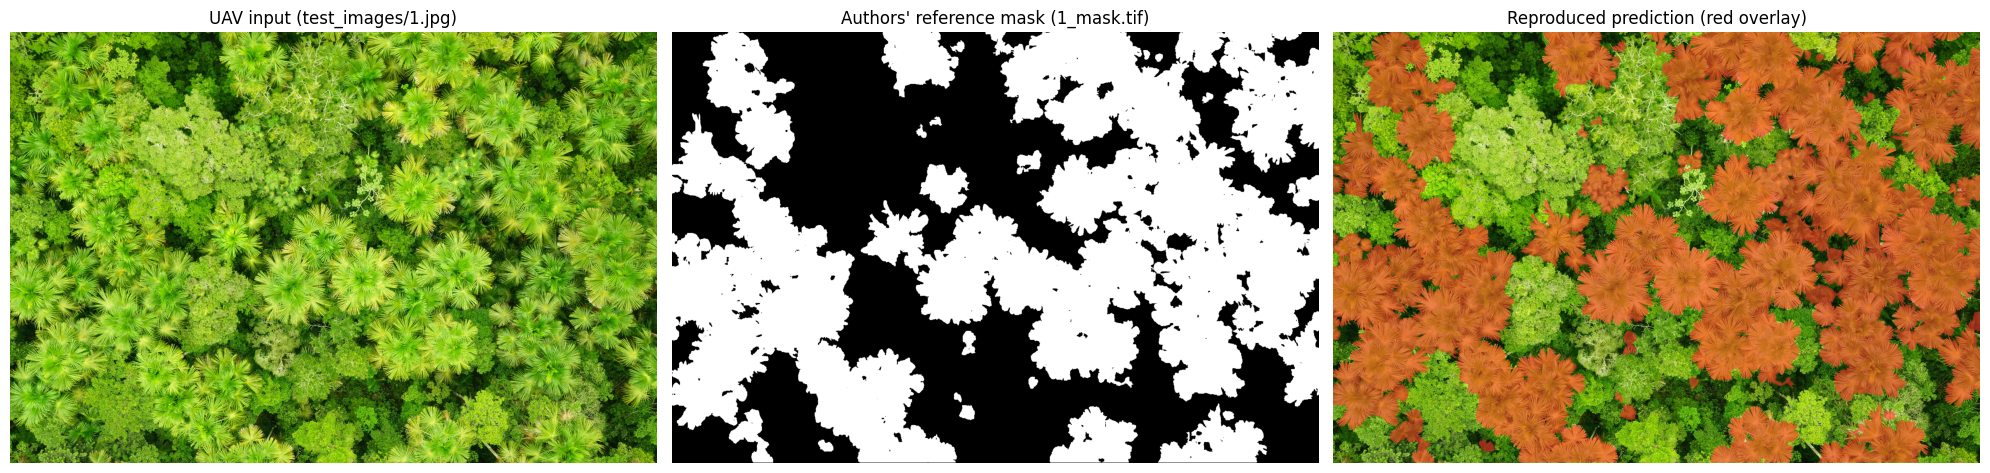

In [ ]:
overlay = img.copy()
overlay[pred_mask > 0] = (overlay[pred_mask > 0] * 0.45 + np.array([255, 40, 40]) * 0.55).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(img);       axes[0].set_title("UAV input (test_images/1.jpg)")
axes[1].imshow(ref, cmap="gray"); axes[1].set_title("Authors' reference mask (1_mask.tif)")
axes[2].imshow(overlay);   axes[2].set_title("Reproduced prediction (red overlay)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Result: probability map and binary mask

The merged probability map (`maskf`, 0–255) before thresholding, and the final binary mask at original
resolution — mirroring the paper's Figure 11 (b)/(c) panel structure for this single image.

**日本語:** 閾値処理前の確率マップ(0–255)と、最終的な二値マスク(元解像度)を表示します。
論文 Figure 11 の (b)/(c) に相当する図です。

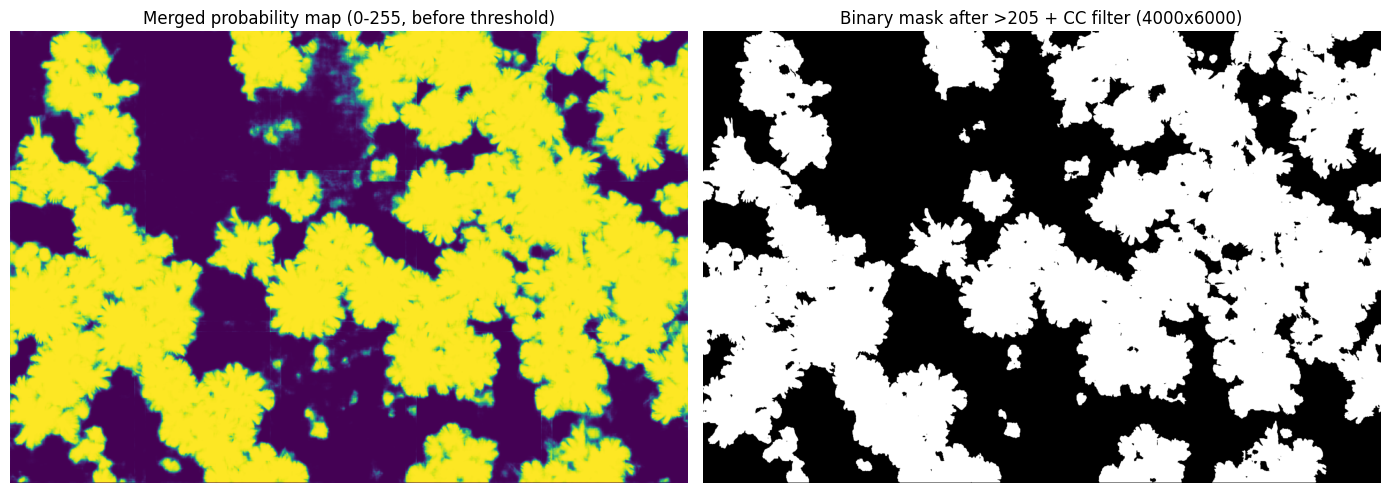

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(maskf, cmap="viridis"); axes[0].set_title("Merged probability map (0-255, before threshold)")
axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("Binary mask after >205 + CC filter (4000x6000)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Quantitative agreement with the authors' released mask

Pixel accuracy and palm-class IoU between our reproduced mask and the authors' released `1_mask.tif`, plus
run metadata (tile count, device). This is a **plausibility check against the authors' own output**, not the
paper's test-set evaluation (98.143% accuracy is a dataset-level figure over the 2.5% test split and is not
recomputable from a single image).

**日本語:** 再現マスクと著者公開マスクの一致率・IoU を算定します。これは著者自身の出力との一致確認で
あり、論文のテストセット評価(98.143%)の再計算ではありません。

In [ ]:
import pandas as pd

p, g = (pred_mask > 0), (ref > 0)
acc = float((p == g).mean())
iou = float((p & g).sum() / max((p | g).sum(), 1))
dev = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"

results = pd.DataFrame([
    {"metric": "pixel_accuracy_vs_reference", "value": round(acc, 6)},
    {"metric": "palm_IoU_vs_reference",       "value": round(iou, 6)},
    {"metric": "tiles_processed",             "value": n1 * n2},
    {"metric": "components_kept",             "value": kept},
    {"metric": "prediction_seconds_cpu_tiles", "value": round(pred_sec, 2)},
    {"metric": "device_reported",             "value": dev},
])
display(results)
results.to_csv("/content/mauflex/mauflex_1jpg_results.csv", index=False)
print("saved /content/mauflex/mauflex_1jpg_results.csv")

,metric,value
0,pixel_accuracy_vs_reference,1.0
1,palm_IoU_vs_reference,1.0
2,tiles_processed,15
3,components_kept,23
4,prediction_seconds_cpu_tiles,19.24
5,device_reported,CPU


saved /content/mauflex/mauflex_1jpg_results.csv


## Interpretation, limitations, references

**Interpretation.** The reproduced pipeline — the authors' own released weights and window logic — segments
the *Mauritia flexuosa* crowns in `1.jpg`; agreement with the authors' released mask is reported in the table
above. Small differences are expected from framework/library version changes (TF 2.21 vs the authors' 2018-era
Keras/TF) and image-resize interpolation differences, and would not indicate a method change.

**Limitations.** One image; no training; no georeferenced GeoTIFF export (the GDAL write block of
`detectaguaje` is omitted — Colab outputs are plain PNG/CSV under `/content/mauflex/`); the mosaic-monitoring
stage (paper §3.3) is out of scope; the paper's headline metrics are not recomputed here.

**Provenance.** Code: `aguaje_functions.py` @ commit `71c6c236…` (https://github.com/GiorgioMorales/MauFlex).
Weights/inputs from the same commit; blob SHA-1s verified. Method: *Forests* 2018, 9(12), 736,
DOI 10.3390/f9120736. No license file is present in the author repository; artifacts are fetched directly from
the authors' public repository for research/educational use — redistribution terms are those of the original
repository. Dataset (MauFlex_Dataset.rar, CC-BY-NC-SA 4.0 per the article) was **not** used.

**日本語:** 著者自身の公開重みと窓処理をそのまま用いた 1 枚画像の再現です。バージョン差(TF 2.21 vs
2018 年頃の Keras/TF)による微小差はあり得ます。学習・ジオレファレンス TIFF 出力・モザイク監視は対象外。
データセット(CC-BY-NC-SA 4.0)は使用していません。著者リポジトリにライセンスファイルはないため、
再配布条件は原著リポジトリの規約に従います。